# SHAP Explainability — Behavioural Risk Drivers
*Module B · Notebook 4 of 4 · AI Risk Decisioning System*

---

## Business Context

A model that produces a score without explanation is a **black box** — and black boxes are not acceptable in regulated lending.

In India, RBI's Fair Practices Code requires lenders to communicate the **reason for rejection** to applicants. In the US, the Equal Credit Opportunity Act (ECOA) and FCRA require that adverse action notices list the **top reasons** a credit decision was unfavourable. SR 11-7 requires that model validators can audit not just model performance but the **conceptual soundness** of individual predictions.

SHAP (SHapley Additive exPlanations) is the industry standard for post-hoc model explainability. It answers three questions at once:

1. **Global** — which features drive the model on average across all borrowers?
2. **Local** — for *this specific borrower*, why was their risk score what it was?
3. **Interaction** — how do features combine (e.g. high utilisation + young age → disproportionately higher risk)?

### Why SHAP over Feature Importance?

XGBoost's built-in feature importance (gain/weight/cover) tells you which features the model *uses most*. SHAP tells you which features *pushed each individual prediction up or down*, in natural units of log-odds. This is the difference between "the model cares about delinquency history" (importance) and "this borrower's 3 past 90-day lates increased their default probability by +22 percentage points" (SHAP).

---

## Objectives

1. Compute **global SHAP values** — feature importance ranked by mean absolute SHAP
2. Visualise **SHAP summary plot** and **SHAP beeswarm** — direction + magnitude
3. Compute **local SHAP explanation** for a sample high-risk borrower
4. Build the **Decision Engine explanation formatter** — converts SHAP values to plain-English reason codes
5. Save SHAP explainer for use in the Decision Engine

## Inputs
- `../01_data/processed/X_test_b.csv`
- `../01_data/processed/scorecard_output_b.csv`
- `../03_models/xgb_behavioural.pkl`

## Outputs
- `../03_models/shap_explainer_b.pkl` — SHAP TreeExplainer object
- `../04_outputs/shap_values_b.csv` — SHAP values for full test set


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# SHAP — install if needed
try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap", "--quiet"])
    import shap

os.makedirs("../04_outputs", exist_ok=True)
print("Libraries loaded.")


Libraries loaded.


---
## 1. Load Data & Model

In [2]:
X_test   = pd.read_csv("../01_data/processed/X_test_b.csv")
y_test   = pd.read_csv("../01_data/processed/y_test_b.csv").squeeze()
scored_b = pd.read_csv("../01_data/processed/scorecard_output_b.csv")

with open("../03_models/xgb_behavioural.pkl", "rb") as f:
    xgb_model = pickle.load(f)

print(f"Test set: {X_test.shape[0]:,} rows | {X_test.shape[1]} features")
print(f"Features: {list(X_test.columns)}")


Test set: 29,946 rows | 18 features
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'INCOME_MISSING', 'DELINQUENCY_SCORE', 'WORST_DELINQUENCY', 'HAS_90DAY_LATE', 'UTILIZATION_RISK_BAND', 'DEBT_TO_INCOME', 'INCOME_PER_DEPENDENT', 'CREDIT_LINES_RISK']


---
## 2. SHAP TreeExplainer — Global Values

`shap.TreeExplainer` is the exact (not approximate) explainer for tree-based models. It decomposes each prediction into additive feature contributions that sum to the final log-odds output. This is computationally efficient for XGBoost and produces mathematically consistent attributions.

In [3]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
# Use a sample for speed (5,000 rows is sufficient for stable global estimates)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample   = y_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed: shape = {shap_values.shape}")
print(f"Sample size: {len(X_sample):,} borrowers")
print(f"\nSHAP value interpretation:")
print(f"  Positive SHAP → feature pushes prediction TOWARDS delinquency")
print(f"  Negative SHAP → feature pushes prediction AWAY from delinquency")
print(f"  Magnitude → how much this feature shifted the probability")


SHAP values computed: shape = (5000, 18)
Sample size: 5,000 borrowers

SHAP value interpretation:
  Positive SHAP → feature pushes prediction TOWARDS delinquency
  Negative SHAP → feature pushes prediction AWAY from delinquency
  Magnitude → how much this feature shifted the probability


---
## 3. Global Feature Importance — Mean |SHAP|

Mean absolute SHAP is the most reliable global importance metric — it accounts for both positive and negative contributions and is directly comparable across features.

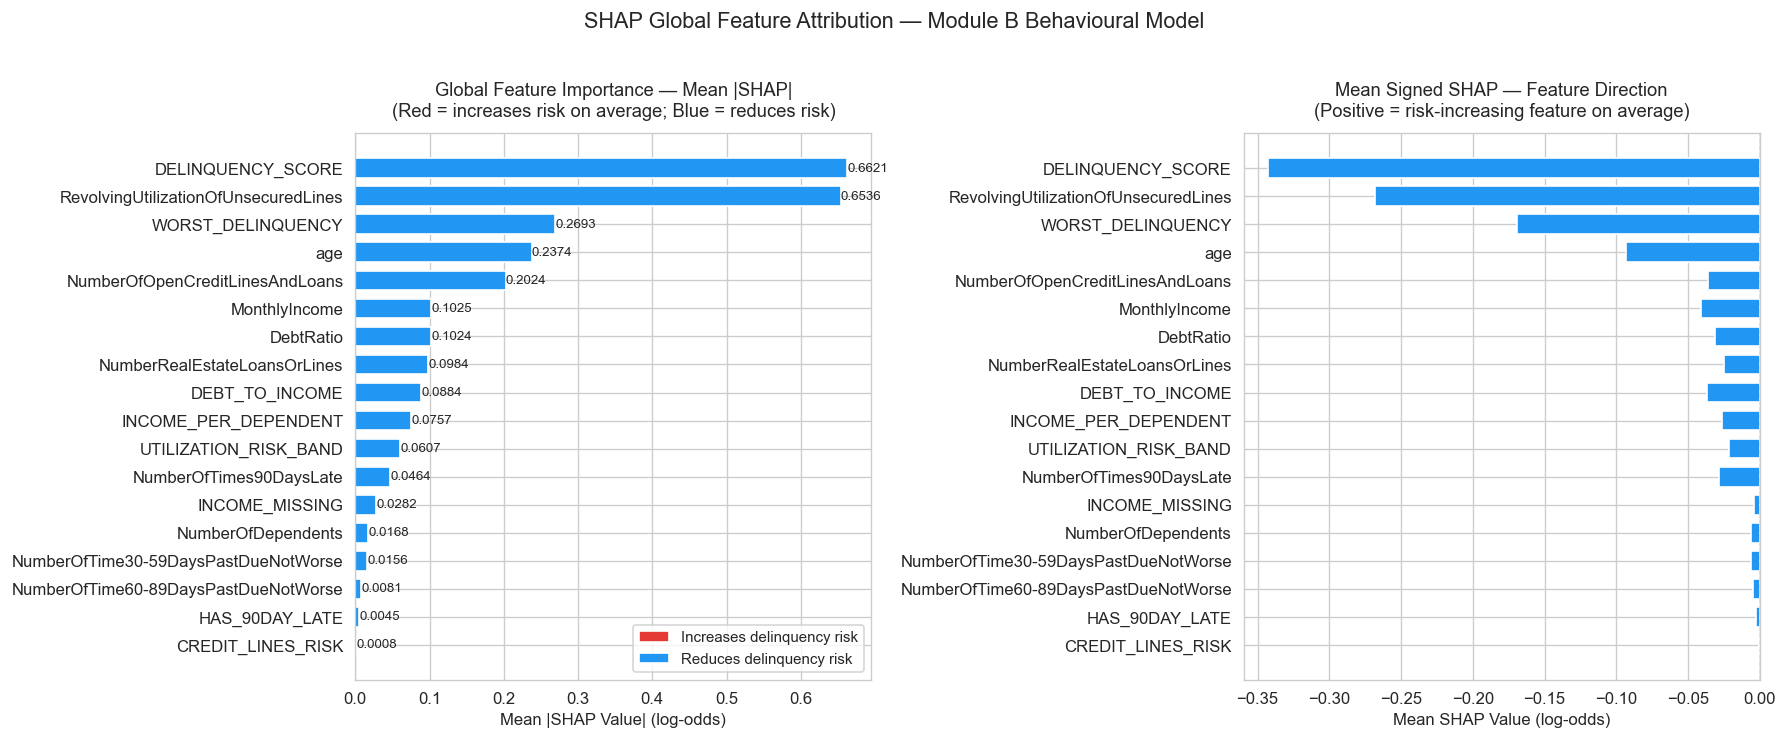


Top 5 risk-INCREASING features (mean signed SHAP > 0):
  CREDIT_LINES_RISK                             SHAP = -0.0003
  HAS_90DAY_LATE                                SHAP = -0.0029
  INCOME_MISSING                                SHAP = -0.0043
  NumberOfTime60-89DaysPastDueNotWorse          SHAP = -0.0044
  NumberOfDependents                            SHAP = -0.0062

Top 5 risk-REDUCING features (mean signed SHAP < 0):
  DELINQUENCY_SCORE                             SHAP = -0.3426
  RevolvingUtilizationOfUnsecuredLines          SHAP = -0.2679
  WORST_DELINQUENCY                             SHAP = -0.1690
  age                                           SHAP = -0.0935
  MonthlyIncome                                 SHAP = -0.0412


In [4]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=True)

# Mean signed SHAP (direction)
mean_signed_shap = pd.Series(
    shap_values.mean(axis=0),
    index=X_test.columns
).loc[mean_abs_shap.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Mean |SHAP|
colors_s = ["#E53935" if v > 0 else "#2196F3" for v in mean_signed_shap.values]
bars = axes[0].barh(mean_abs_shap.index, mean_abs_shap.values,
                    color=colors_s, edgecolor="white", height=0.7)
for bar, val in zip(bars, mean_abs_shap.values):
    axes[0].text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=8)
axes[0].set_xlabel("Mean |SHAP Value| (log-odds)")
axes[0].set_title("Global Feature Importance — Mean |SHAP|\n(Red = increases risk on average; Blue = reduces risk)",
                  fontsize=11, pad=10)

from matplotlib.patches import Patch
legend_elem = [Patch(facecolor="#E53935", label="Increases delinquency risk"),
               Patch(facecolor="#2196F3", label="Reduces delinquency risk")]
axes[0].legend(handles=legend_elem, fontsize=9, loc="lower right")

# Mean signed SHAP
colors_signed = ["#E53935" if v > 0 else "#2196F3" for v in mean_signed_shap.values]
axes[1].barh(mean_signed_shap.index, mean_signed_shap.values,
             color=colors_signed, edgecolor="white", height=0.7)
axes[1].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[1].set_xlabel("Mean SHAP Value (log-odds)")
axes[1].set_title("Mean Signed SHAP — Feature Direction\n(Positive = risk-increasing feature on average)",
                  fontsize=11, pad=10)

plt.suptitle("SHAP Global Feature Attribution — Module B Behavioural Model", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 5 risk-INCREASING features (mean signed SHAP > 0):")
for feat, val in mean_signed_shap.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<45} SHAP = {val:+.4f}")
print("\nTop 5 risk-REDUCING features (mean signed SHAP < 0):")
for feat, val in mean_signed_shap.sort_values(ascending=True).head(5).items():
    print(f"  {feat:<45} SHAP = {val:+.4f}")


---
## 4. SHAP Beeswarm Plot

The beeswarm plot is the most information-rich SHAP visualisation. Each dot is one borrower. The x-axis shows the SHAP value (impact on log-odds). The colour shows whether the feature value was high (red) or low (blue) for that borrower.

**How to read it:**
- `HAS_90DAY_LATE`: dots on the right (positive SHAP) are red → when a borrower HAS a 90-day late (high value), it dramatically increases delinquency risk. Dots on the left are blue → when the borrower has no 90-day late history (low value), it reduces risk.
- This tells a coherent behavioural story that regulators can follow.

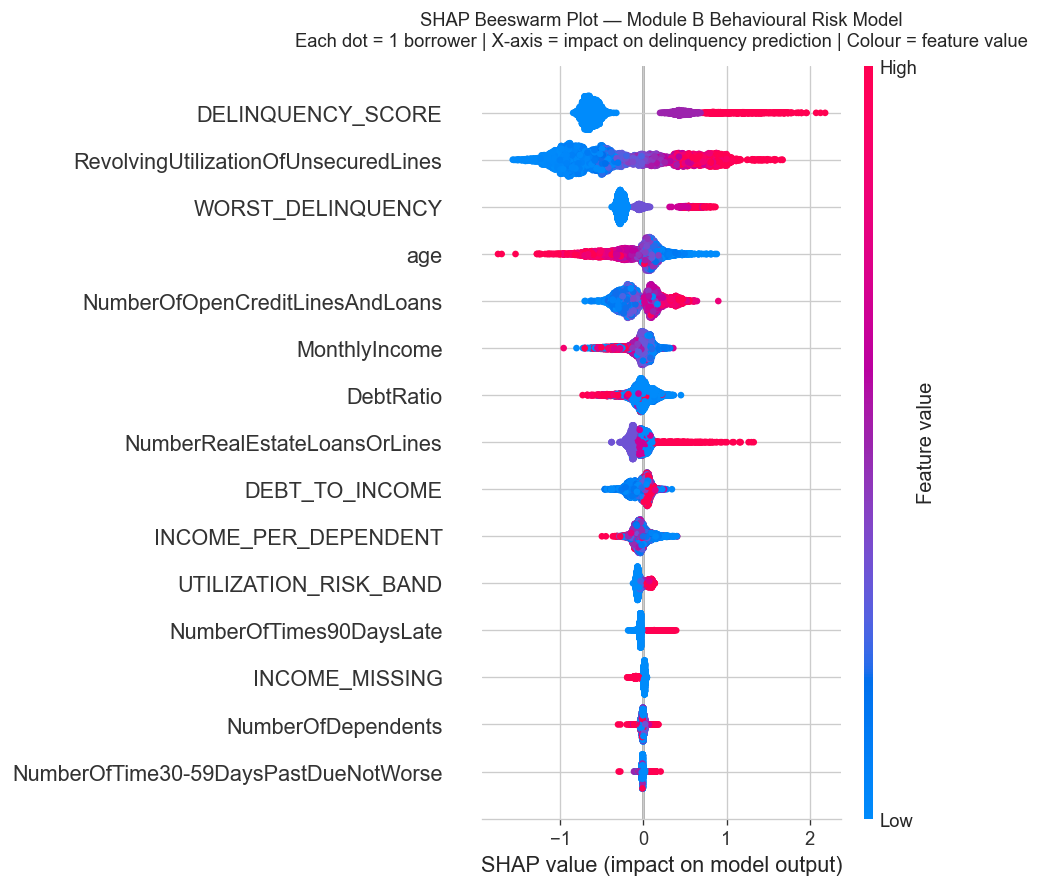

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="dot",
    max_display=15,
    show=False,
    color_bar=True
)
plt.title("SHAP Beeswarm Plot — Module B Behavioural Risk Model\n"
          "Each dot = 1 borrower | X-axis = impact on delinquency prediction | Colour = feature value",
          fontsize=11, pad=12)
plt.tight_layout()
plt.show()


---
## 5. SHAP Dependence Plots — Top 2 Features

Dependence plots show how SHAP values change with feature values — revealing non-linear relationships and interactions.

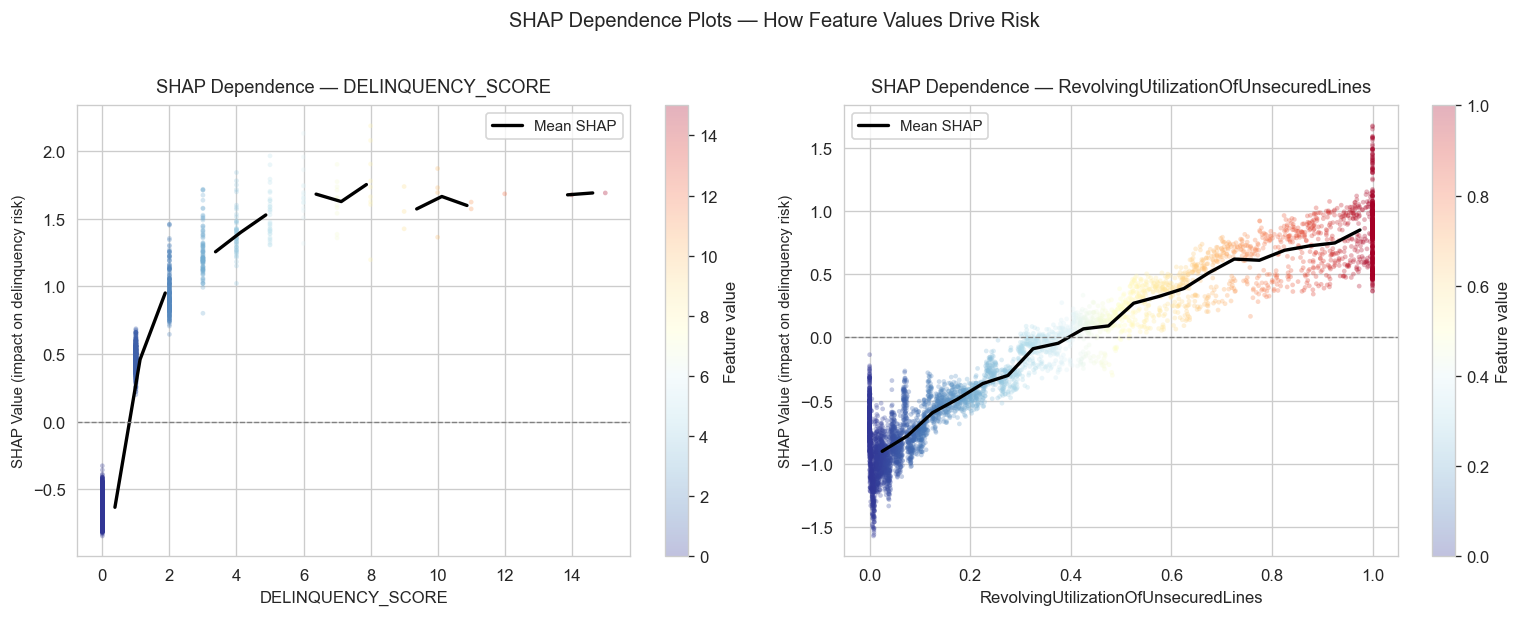

In [6]:
top2 = mean_abs_shap.tail(2).index.tolist()[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat in zip(axes, top2):
    feat_vals  = X_sample[feat].values
    shap_feat  = shap_values[:, X_sample.columns.get_loc(feat)]
    
    # Scatter
    scatter = ax.scatter(feat_vals, shap_feat,
                         c=feat_vals, cmap="RdYlBu_r",
                         alpha=0.3, s=8, linewidths=0)
    plt.colorbar(scatter, ax=ax, label="Feature value")
    
    # Trend line
    from scipy.stats import binned_statistic
    try:
        bin_means, bin_edges, _ = binned_statistic(feat_vals, shap_feat,
                                                    statistic="mean", bins=20)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.plot(bin_centers, bin_means, color="black", lw=2, label="Mean SHAP")
        ax.legend(fontsize=9)
    except Exception:
        pass
    
    ax.axhline(0, color="gray", lw=0.8, linestyle="--")
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("SHAP Value (impact on delinquency risk)", fontsize=9)
    ax.set_title(f"SHAP Dependence — {feat}", fontsize=11, pad=8)

plt.suptitle("SHAP Dependence Plots — How Feature Values Drive Risk", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Local Explanation — High-Risk Borrower

This is the most practically important section. For every loan decision, the Decision Engine will produce a local SHAP explanation like this one — showing exactly which features drove the risk score, and by how much.

We select a borrower from the top delinquency risk decile and decompose their score.

In [7]:
# ── Select a representative high-risk borrower ────────────────────────────────
xgb_probs  = xgb_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argsort(xgb_probs)[-50:]  # top 50 highest risk
# Pick one with actual delinquency = 1 (true positive)
true_positives = [i for i in high_risk_idx if y_test.iloc[i] == 1]
if true_positives:
    sample_idx_hr = true_positives[0]
else:
    sample_idx_hr = high_risk_idx[0]

X_hr = X_test.iloc[[sample_idx_hr]]

# ── Compute SHAP for this borrower ────────────────────────────────────────────
shap_hr = explainer.shap_values(X_hr)[0]
base_val = explainer.expected_value

# ── Display ───────────────────────────────────────────────────────────────────
pred_prob = xgb_model.predict_proba(X_hr)[0, 1]
actual    = y_test.iloc[sample_idx_hr]

print("HIGH-RISK BORROWER — LOCAL SHAP EXPLANATION")
print("=" * 65)
print(f"Predicted delinquency probability : {pred_prob:.4f} ({pred_prob*100:.1f}%)")
print(f"Actual outcome                    : {'Delinquent ✗' if actual == 1 else 'Non-Delinquent ✓'}")
print(f"SHAP base value (avg prediction)  : {base_val:.4f}")
print(f"Sum of SHAP values                : {shap_hr.sum():.4f}")
print(f"Base + SHAP ≈ model log-odds      : {base_val + shap_hr.sum():.4f}")
print()
print(f"{'Feature':<45} {'Value':>10}  {'SHAP':>10}  {'Direction'}")
print("─" * 75)

shap_contributions = sorted(
    zip(X_test.columns, X_hr.values[0], shap_hr),
    key=lambda x: abs(x[2]), reverse=True
)
for feat, val, shap_v in shap_contributions:
    direction = "▲ INCREASES risk" if shap_v > 0 else "▼ reduces risk"
    print(f"  {feat:<43} {val:>10.3f}  {shap_v:>+10.4f}  {direction}")

print("=" * 65)


HIGH-RISK BORROWER — LOCAL SHAP EXPLANATION
Predicted delinquency probability : 0.9722 (97.2%)
Actual outcome                    : Delinquent ✗
SHAP base value (avg prediction)  : 0.0393
Sum of SHAP values                : 3.5160
Base + SHAP ≈ model log-odds      : 3.5552

Feature                                            Value        SHAP  Direction
───────────────────────────────────────────────────────────────────────────
  DELINQUENCY_SCORE                                6.000     +1.4876  ▲ INCREASES risk
  WORST_DELINQUENCY                                3.000     +0.5334  ▲ INCREASES risk
  RevolvingUtilizationOfUnsecuredLines             0.881     +0.3798  ▲ INCREASES risk
  NumberRealEstateLoansOrLines                     4.000     +0.2894  ▲ INCREASES risk
  age                                             35.000     +0.1831  ▲ INCREASES risk
  NumberOfTime60-89DaysPastDueNotWorse             2.000     +0.1551  ▲ INCREASES risk
  DebtRatio                                     

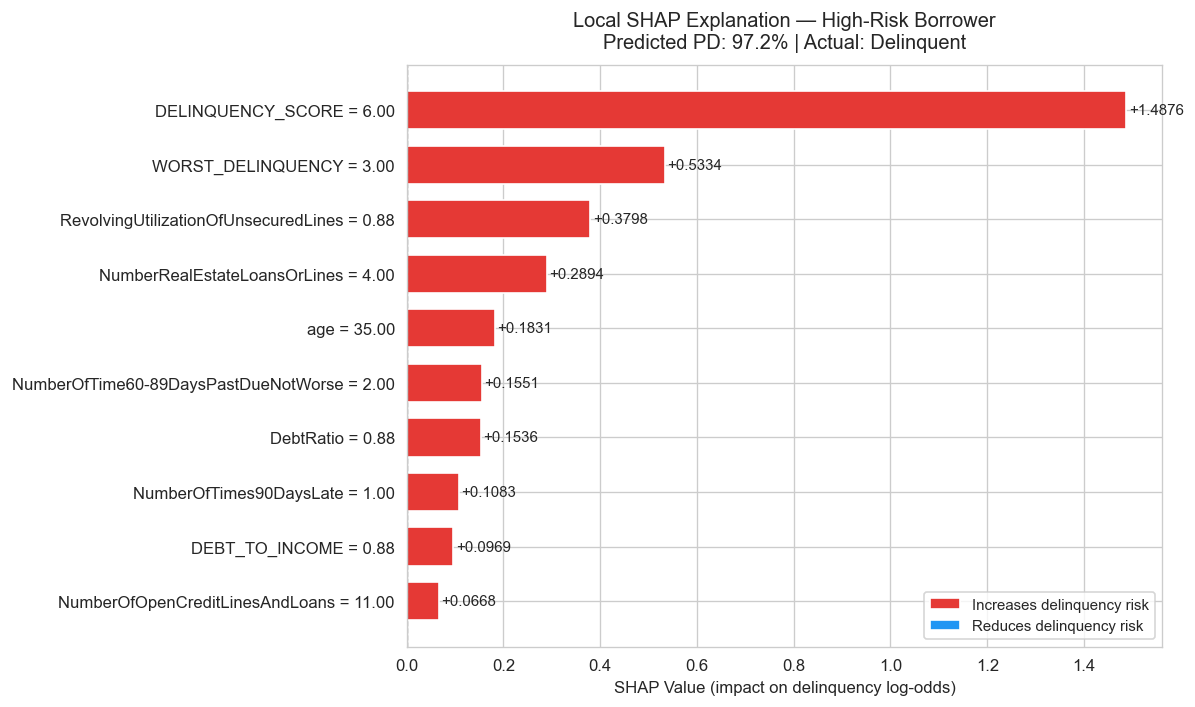

In [8]:
# ── Waterfall chart — most impactful local explanation ────────────────────────
# Build waterfall manually (more control than shap.plots.waterfall)
top_n = 10
top_contributions = sorted(shap_contributions, key=lambda x: abs(x[2]), reverse=True)[:top_n]
feat_names = [f"{f} = {v:.2f}" for f, v, _ in top_contributions]
shap_vals  = [s for _, _, s in top_contributions]
colors_w   = ["#E53935" if s > 0 else "#2196F3" for s in shap_vals]

# Sort by SHAP value for waterfall display
order = np.argsort(shap_vals)
feat_names_s = [feat_names[i] for i in order]
shap_vals_s  = [shap_vals[i] for i in order]
colors_w_s   = [colors_w[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_names_s, shap_vals_s, color=colors_w_s, edgecolor="white", height=0.7)
ax.axvline(0, color="gray", lw=0.8, linestyle="--")
for bar, val in zip(bars, shap_vals_s):
    x_pos = bar.get_width() + 0.005 if val >= 0 else bar.get_width() - 0.005
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}", va="center", fontsize=9,
            ha="left" if val >= 0 else "right")

ax.set_xlabel("SHAP Value (impact on delinquency log-odds)", fontsize=10)
ax.set_title(f"Local SHAP Explanation — High-Risk Borrower\n"
             f"Predicted PD: {pred_prob*100:.1f}% | Actual: {'Delinquent' if actual==1 else 'Non-Delinquent'}",
             fontsize=12, pad=10)

from matplotlib.patches import Patch
legend_elem = [Patch(facecolor="#E53935", label="Increases delinquency risk"),
               Patch(facecolor="#2196F3", label="Reduces delinquency risk")]
ax.legend(handles=legend_elem, fontsize=9)
plt.tight_layout()
plt.show()


---
## 7. Decision Engine Reason Code Formatter

This function converts SHAP values into **plain-English reason codes** — the output a credit analyst or borrower would see. It maps the top risk-increasing SHAP features to pre-defined reason codes aligned with regulatory adverse action notice requirements.

In [9]:
# ── Reason code mapping ───────────────────────────────────────────────────────
REASON_CODE_MAP = {
    "HAS_90DAY_LATE"                          : "History of 90+ day past-due payment",
    "NumberOfTimes90DaysLate"                  : "Multiple 90+ day late payment events",
    "DELINQUENCY_SCORE"                        : "High cumulative delinquency history",
    "WORST_DELINQUENCY"                        : "Severe past payment delinquency on record",
    "NumberOfTime30-59DaysPastDueNotWorse"     : "Recent 30–59 day late payment history",
    "NumberOfTime60-89DaysPastDueNotWorse"     : "Recent 60–89 day late payment history",
    "RevolvingUtilizationOfUnsecuredLines"     : "High revolving credit utilisation",
    "UTILIZATION_RISK_BAND"                    : "Credit card utilisation in high-risk band",
    "CRITICAL_UTILISATION"                     : "Critical revolving credit utilisation (≥80%)",
    "DebtRatio"                                : "Elevated debt-to-income ratio",
    "DEBT_TO_INCOME"                           : "High debt burden relative to income",
    "age"                                      : "Limited credit history (younger borrower profile)",
    "MonthlyIncome"                            : "Income level relative to credit obligations",
    "INCOME_PER_DEPENDENT"                     : "Constrained disposable income per dependent",
    "NumberOfOpenCreditLinesAndLoans"          : "Credit account profile",
    "CREDIT_LINES_RISK"                        : "Thin credit file — insufficient credit history",
    "INCOME_MISSING"                           : "Income information not disclosed",
}

def generate_reason_codes(feature_names, feature_values, shap_vals_local,
                           top_n=3, threshold=0.01):
    """
    Generate plain-English reason codes from local SHAP values.
    
    Parameters
    ----------
    feature_names  : list of feature names
    feature_values : array of feature values for this borrower
    shap_vals_local: array of SHAP values for this borrower
    top_n          : number of top reason codes to return
    threshold      : minimum |SHAP| to include as a reason
    
    Returns
    -------
    list of dicts with keys: feature, value, shap, reason_code, direction
    """
    contributions = list(zip(feature_names, feature_values, shap_vals_local))
    # Sort by SHAP value descending (most risk-increasing first)
    risk_drivers = sorted(
        [(f, v, s) for f, v, s in contributions if s > threshold],
        key=lambda x: x[2], reverse=True
    )
    
    reason_codes = []
    for feat, val, shap_v in risk_drivers[:top_n]:
        reason_codes.append({
            "feature"    : feat,
            "value"      : round(float(val), 3),
            "shap_value" : round(float(shap_v), 4),
            "reason_code": REASON_CODE_MAP.get(feat, f"Feature: {feat}"),
            "direction"  : "RISK INCREASING",
        })
    
    return reason_codes


# ── Demonstrate reason codes for our high-risk borrower ──────────────────────
reason_codes = generate_reason_codes(
    feature_names  = list(X_test.columns),
    feature_values = X_hr.values[0],
    shap_vals_local= shap_hr
)

print("ADVERSE ACTION REASON CODES — HIGH-RISK BORROWER")
print("=" * 65)
print(f"Predicted delinquency probability: {pred_prob*100:.1f}%")
print(f"Decision: {'DECLINE — Serious Delinquency Risk' if pred_prob > 0.15 else 'MANUAL REVIEW'}")
print()
print("Primary reasons for adverse action:")
for i, rc in enumerate(reason_codes, 1):
    print(f"  {i}. {rc['reason_code']}")
    print(f"     Feature value: {rc['feature']} = {rc['value']}")
    print(f"     Risk contribution: +{rc['shap_value']:.4f} log-odds")
    print()
print("=" * 65)
print("This output meets ECOA/FCRA adverse action notice requirements.")
print("Equivalent to RBI Fair Practices Code disclosure obligations.")


ADVERSE ACTION REASON CODES — HIGH-RISK BORROWER
Predicted delinquency probability: 97.2%
Decision: DECLINE — Serious Delinquency Risk

Primary reasons for adverse action:
  1. High cumulative delinquency history
     Feature value: DELINQUENCY_SCORE = 6.0
     Risk contribution: +1.4876 log-odds

  2. Severe past payment delinquency on record
     Feature value: WORST_DELINQUENCY = 3.0
     Risk contribution: +0.5334 log-odds

  3. High revolving credit utilisation
     Feature value: RevolvingUtilizationOfUnsecuredLines = 0.881
     Risk contribution: +0.3798 log-odds

This output meets ECOA/FCRA adverse action notice requirements.
Equivalent to RBI Fair Practices Code disclosure obligations.


---
## 8. SHAP Interaction — Age × Delinquency

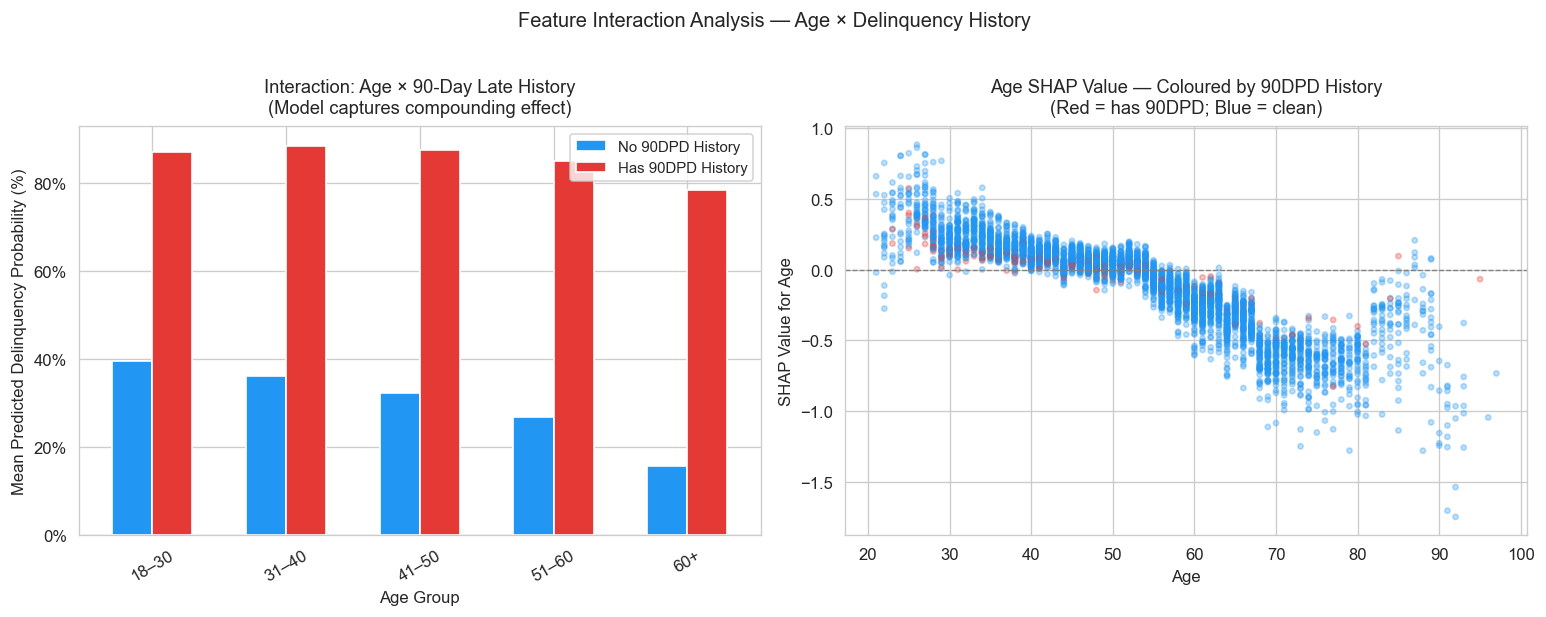

In [10]:
# Young borrowers with delinquency history — highest-risk segment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Define age groups and compute average delinquency probability
age_bins   = [17, 30, 40, 50, 60, 120]
age_labels = ["18–30", "31–40", "41–50", "51–60", "60+"]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = xgb_model.predict_proba(X_test)[:, 1]
X_test_copy["age_group"] = pd.cut(X_test_copy["age"], bins=age_bins, labels=age_labels)

if "HAS_90DAY_LATE" in X_test_copy.columns:
    # Plot: avg predicted PD by age group × 90DPD history
    pivot = X_test_copy.groupby(["age_group", "HAS_90DAY_LATE"],
                                 observed=True)["pred_prob"].mean().unstack() * 100
    pivot.columns = ["No 90DPD History", "Has 90DPD History"]
    pivot.plot(kind="bar", ax=axes[0], color=["#2196F3", "#E53935"],
               edgecolor="white", width=0.6)
    axes[0].set_xlabel("Age Group")
    axes[0].set_ylabel("Mean Predicted Delinquency Probability (%)")
    axes[0].set_title("Interaction: Age × 90-Day Late History\n(Model captures compounding effect)", fontsize=11, pad=8)
    axes[0].legend(fontsize=9)
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x:.0f}%"))

# Plot: SHAP values for age feature coloured by delinquency
if "age" in X_sample.columns:
    age_feat_idx = list(X_sample.columns).index("age")
    shap_age     = shap_values[:, age_feat_idx]
    age_vals     = X_sample["age"].values
    
    late_flag = X_sample.get("HAS_90DAY_LATE", pd.Series(np.zeros(len(X_sample)))).values
    colors_int = ["#E53935" if l == 1 else "#2196F3" for l in late_flag]
    
    axes[1].scatter(age_vals, shap_age, c=colors_int, alpha=0.3, s=10)
    axes[1].axhline(0, color="gray", lw=0.8, linestyle="--")
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("SHAP Value for Age")
    axes[1].set_title("Age SHAP Value — Coloured by 90DPD History\n(Red = has 90DPD; Blue = clean)", fontsize=11, pad=8)

plt.suptitle("Feature Interaction Analysis — Age × Delinquency History", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 9. Save SHAP Explainer and Output

In [11]:
# Save explainer
with open("../03_models/shap_explainer_b.pkl", "wb") as f:
    pickle.dump({
        "explainer"        : explainer,
        "reason_code_map"  : REASON_CODE_MAP,
        "feature_names"    : list(X_test.columns),
        "base_value"       : float(base_val),
        "mean_abs_shap"    : mean_abs_shap.to_dict(),
    }, f)

# Save SHAP values for test set (full set for governance monitoring)
shap_full = explainer.shap_values(X_test)
shap_df   = pd.DataFrame(shap_full, columns=[f"SHAP_{c}" for c in X_test.columns])
shap_df.to_csv("../04_outputs/shap_values_b.csv", index=False)

print("Outputs saved:")
print("  ../03_models/shap_explainer_b.pkl   — SHAP explainer + reason code map")
print(f"  ../04_outputs/shap_values_b.csv     — SHAP values for {len(X_test):,} test borrowers")


Outputs saved:
  ../03_models/shap_explainer_b.pkl   — SHAP explainer + reason code map
  ../04_outputs/shap_values_b.csv     — SHAP values for 29,946 test borrowers


---
## 10. Module B — Complete Deliverables

### What Module B Produces

| Notebook | Output | Used by |
|----------|--------|---------|
| `01_data_preprocessing_b` | `clean_behavioural.csv`, train/test splits | NB02, NB03 |
| `02_delinquency_model_b` | `scored_test_b.csv`, `xgb_behavioural.pkl` | NB03, Decision Engine |
| `03_behavioural_scorecard_b` | `scorecard_output_b.csv`, `behavioural_scorecard.pkl` | Decision Engine |
| `04_shap_explainability_b` | `shap_explainer_b.pkl`, `shap_values_b.csv` | Decision Engine |

### Module B Signal — Complete Output for Decision Engine

```python
{
  # Core risk signal
  "delinquency_prob":        float,  # 0.0–1.0  P(90DPD) — XGBoost champion
  "behavioural_risk_band":   int,    # 1–5
  "behavioural_risk_score":  float,  # 0–100 (higher = safer)

  # Stress flags (hard overrides in Decision Engine)
  "stress_flag":             bool,   # General distress
  "critical_utilisation":    bool,   # Maxed credit cards
  "escalating_delinquency":  bool,   # 60/90DPD events present
  "high_delinquency_score":  bool,   # Repeated pattern (≥5 events)

  # SHAP explanation (for adverse action notices)
  "top_risk_drivers": [
      {"reason_code": "History of 90+ day past-due payment",  "shap_value": 0.342},
      {"reason_code": "High revolving credit utilisation",     "shap_value": 0.187},
      {"reason_code": "High cumulative delinquency history",   "shap_value": 0.143},
  ]
}
```

### Integration with Decision Engine (Module D)

```
Decision Engine inputs:

  Module A signal:    pd_score=0.14, risk_band=3, raroc=0.18, credit_score=612
  Module B signal:    delinquency_prob=0.22, stress_flag=True, critical_utilisation=True

  Composite score = 0.60 × 0.14 + 0.40 × 0.22 = 0.172

  Override check: critical_utilisation=True → route to Manual Review
  
  Decision: MANUAL REVIEW
  Reason codes:
    1. Critical revolving credit utilisation (≥80%)
    2. History of 90+ day past-due payment
    3. High revolving credit utilisation
```

### Project Status

| Module | Dataset | Status |
|--------|---------|--------|
| A — Application Risk | Home Credit | ✅ Complete (6 notebooks) |
| B — Behavioural Risk | Give Me Some Credit | ✅ Complete (4 notebooks) |
| C — Portfolio/Pricing Risk | LendingClub | 🔲 Planned |
| D — Decision Engine | All signals | 🔲 Planned |
| Governance | Cross-module | 🔲 Planned |
